In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, '..')

from utilities_notebook import zscore_normalize_features, apply_zscore_normalization

pd.options.display.float_format = '{:0.4f}'.format

In [2]:
X_train = pd.read_csv("../data/linear/X_train.csv", index_col=0, parse_dates=True)
y_train = pd.read_csv("../data/linear/y_train.csv", index_col=0, parse_dates=True)
X_test = pd.read_csv("../data/linear/X_test.csv", index_col=0, parse_dates=True)
y_test = pd.read_csv("../data/linear/y_test.csv", index_col=0, parse_dates=True)

print(f"Shape\n"
      f"X_train: {X_train.shape}, y_train: {y_train.shape}\n"
      f"X_test:  {X_test.shape}, y_test : {y_test.shape}\n")

X_train.head()

Shape
X_train: (567, 6), y_train: (567, 1)
X_test:  (144, 6), y_test : (144, 1)



,volume,pct_change_1d,rsi,adx,corr,volatility
Date,,,,,,
2023-02-02,8523200,-0.0263,25.7174,20.0382,0.6622,1.5033
2023-02-03,9219400,0.0270,39.1583,23.3035,0.7018,1.8069
2023-02-07,11662300,-0.0368,30.5574,27.4843,0.8373,2.0947
2023-02-08,5665300,0.0109,35.0839,31.2471,0.8722,2.1606
2023-02-09,6074700,0.0054,37.3526,33.7873,0.8379,2.1827


Logistic Regression for Classification Model

In [3]:
# sigmoid function
def sigmoid(X):
    X = np.clip(X, -500, 500) # protect against overflow
    return 1/(1+np.exp(-X))

In [4]:
# compute cost function

def compute_cost(X, y, w, b, lambda_=0):
    """
    Computes cost

    Args:
        X (ndarray (m,n)) : Data, m examples with n features
        y (ndarray (m,))  : target values
        w (ndarray (n,))  : model parameters
        b (scalar)        : model parameter
    
    Returns:
        cost (scalar)     : cost
    """
    m = X.shape[0]
    z = X @ w + b
    f_wb = sigmoid(z)
    
    # Clip f_wb to be between a tiny epsilon and 1-epsilon
    epsilon = 1e-15
    f_wb = np.clip(f_wb, epsilon, 1 - epsilon)
    
    loss = -y * np.log(f_wb) - (1-y) * np.log(1-f_wb)
    regularized_cost = lambda_ / (2*m) * np.sum(w**2)

    return np.sum(loss) / m + regularized_cost

In [5]:
def compute_gradient(X, y, w, b, lambda_=0):
    """
    Computes the gradient for logistic regression 

    Args:
      X (ndarray (m,n)) : data, m examples by n features
      y (ndarray (m,))  : target value 
      w (ndarray (n,))  : values of parameters of the model
      b (scalar)        : value of bias parameter of the model

    Returns
      dj_dw (ndarray (n,)) : The gradient of the cost w.r.t. the parameters w. 
      dj_db (scalar)       : The gradient of the cost w.r.t. the parameter b. 
    """
    m = X.shape[0]

    # Linear combination and activation
    z = np.dot(X, w) + b
    f_wb = sigmoid(z)
    err = f_wb - y

    # Gradient calculation using matrix multiplication
    dj_dw = np.dot(X.T, err) / m + lambda_ / m * w
    dj_db = np.sum(err) / m

    return dj_dw, dj_db

In [6]:
def run_gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters, lambda_):
    """
    Performs batch gradient descent to learn theta. Updates theta by taking 
    num_iters gradient steps with learning rate alpha
    
    Args:
      X (ndarray (m, n))      : data, m examples by n features
      y (ndarray (m,))        : target value 
      w_in (ndarray (n,))     : Initial values of parameters of the model
      b_in (scalar)           : Initial value of parameter of the model
      cost_function           : function to compute cost
      gradient_function       : function to compute gradient
      alpha (float)           : Learning rate
      num_iters (int)         : number of iterations to run gradient descent
      lambda_ (scalar, float) : regularization constant
      
    Returns:
      w (ndarray (n,))        : Updated values of parameters of the model
      b (scalar)              : Updated value of parameter of the model
      J_history (list)        : Values of cost J at each iteration
    """
    J_history = []
    w = np.copy(w_in)
    b = b_in

    for i in range(num_iters):
        # Calculate gradient and update parameters
        dj_dw, dj_db = gradient_function(X, y, w, b, lambda_)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        
        # Save cost J at each iteration
        cost = cost_function(X, y, w, b, lambda_)
        J_history.append(cost)

        # Print cost at intervals 10% of num_iters
        if i % (num_iters // 10) == 0 or i == (num_iters - 1):
            print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.5f}")
    
    return w, b, J_history

In [7]:
def predict(X, w, b):
    """
    Predict whether the label is 0 or 1 using learned logistic
    regression parameters w
    
    Args:
      X (ndarray (m,n)) : data, m examples by n features
      w (ndarray (n,))  : values of parameters of the model      
      b (scalar)        : value of bias parameter of the model

    Returns:
      p (ndarray (m,))  : The predictions for X using a threshold at 0.5
    """
    f_wb = sigmoid(X @ w + b)

    p = np.where(f_wb >= 0.5, 1, 0)

    return p

In [8]:
features = ['volume', 'rsi', 'adx']
X_train_norm, X_train_mu, X_train_sigma = zscore_normalize_features(X_train, columns=features)
X_test_norm, X_test_mu, X_test_sigma = zscore_normalize_features(X_test, columns=features)

In [9]:
w_in = np.zeros(X_train_norm.shape[1])
b_in = 0

w, b, J_history = run_gradient_descent(X_train_norm.values, y_train.values.reshape(-1), w_in, b_in, compute_cost,
                                       compute_gradient, alpha=0.1, num_iters=50000, lambda_=0)

Iteration    0: Cost  0.68891
Iteration 5000: Cost  0.64971
Iteration 10000: Cost  0.64919
Iteration 15000: Cost  0.64870
Iteration 20000: Cost  0.64824
Iteration 25000: Cost  0.64781
Iteration 30000: Cost  0.64741
Iteration 35000: Cost  0.64704
Iteration 40000: Cost  0.64669
Iteration 45000: Cost  0.64636
Iteration 49999: Cost  0.64606


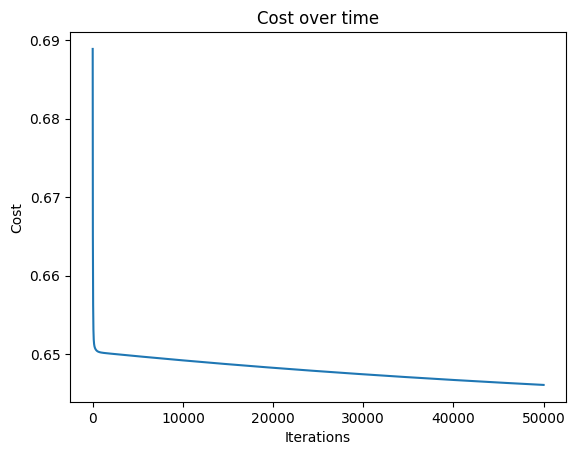

In [10]:
plt.plot(J_history)
plt.title('Cost over time')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.show()

In [11]:
p = predict(X_train_norm, w, b)
print(f"Train accuracy: {np.mean(p==y_train['signal'].values) * 100:.2f}%")

X_test_norm = apply_zscore_normalization(X_test, X_train_mu, X_train_sigma, columns=features)
p2 = predict(X_test_norm, w, b)
print(f"Test accuracy: {np.mean(p2==y_test['signal'].values) * 100:.2f}%")

Train accuracy: 63.49%
Test accuracy: 54.17%


In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(penalty=None, solver='lbfgs', max_iter=10000)

model.fit(X_train_norm, y_train['signal'])

w_sklearn = model.coef_
b_sklearn = model.intercept_

c:\Users\DELL\Workspace\project_01_v2\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [13]:
print(f"w_manual: {w}, b_manual: {b}"
      f"\nw_sklearn:\n{w_sklearn}, b_sklearn: {b_sklearn}")

w_manual: [ 0.43936538 -4.57122222 -0.27524609 -0.06268459  0.25937434 -0.04980683], b_manual: -0.3759003991773029
w_sklearn:
[[  0.45777344 -16.42382969  -0.19589424  -0.06056322   0.2487359
   -0.02849918]], b_sklearn: [-0.41138685]


In [14]:
y_hat = model.predict(X_train_norm)
print(f"Accuracy on training set: {model.score(X_train_norm, y_train['signal']) * 100:0.2f}%")

y_hat2 = model.predict(X_test_norm)
print(f"Accuracy on test set: {model.score(X_test_norm, y_test['signal']) * 100:0.2f}%")

Accuracy on training set: 61.73%
Accuracy on test set: 54.86%


In [15]:
np.savetxt("../data/linear/pred.csv", p2)

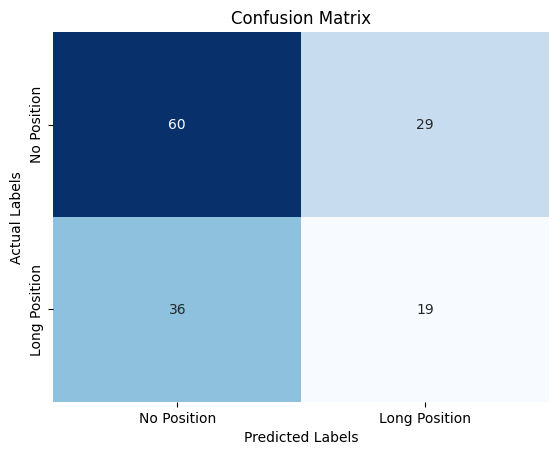

In [16]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

confusion_matrix_data = confusion_matrix(y_test.values, y_hat2)

fig, ax = plt.subplots()
sns.heatmap(confusion_matrix_data, fmt='d', cmap='Blues', cbar=False, annot=True, ax=ax)

ax.set_xlabel('Predicted Labels')
ax.set_ylabel('Actual Labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(['No Position', 'Long Position'])
ax.yaxis.set_ticklabels(['No Position', 'Long Position'])

plt.show()

In [17]:
classification_report_data = classification_report(y_test, y_hat2)

print(classification_report_data)

              precision    recall  f1-score   support

           0       0.62      0.67      0.65        89
           1       0.40      0.35      0.37        55

    accuracy                           0.55       144
   macro avg       0.51      0.51      0.51       144
weighted avg       0.54      0.55      0.54       144



Polynomial logistic regression with regularization

In [18]:
X_poly_train = pd.read_csv("../data/poly/X_poly_train.csv", index_col=0, parse_dates=True)
y_poly_train = pd.read_csv("../data/poly/y_poly_train.csv", index_col=0, parse_dates=True)
X_poly_test = pd.read_csv("../data/poly/X_poly_test.csv", index_col=0, parse_dates=True)
y_poly_test = pd.read_csv("../data/poly/y_poly_test.csv", index_col=0, parse_dates=True)

print(f"Shape\n"
      f"X_poly_train: {X_poly_train.shape}, y_poly_train: {y_poly_train.shape}\n"
      f"X_poly_test:  {X_poly_test.shape}, y_poly_test : {y_poly_test.shape}\n")

X_poly_train.head()

Shape
X_poly_train: (562, 27), y_poly_train: (562, 1)
X_poly_test:  (144, 27), y_poly_test : (144, 1)



,volume,pct_change_1d,rsi,adx,corr,volatility,volume^2,pct_change_1d^2,rsi^2,adx^2,...,pct_change_1d*rsi,pct_change_1d*adx,pct_change_1d*corr,pct_change_1d*volatility,rsi*adx,rsi*corr,rsi*volatility,adx*corr,adx*volatility,corr*volatility
Date,,,,,,,,,,,,,,,,,,,,,
2023-02-02,8523200,-0.0263,25.7174,20.0382,0.6622,1.5033,72644938240000,0.0007,661.3851,401.5280,...,-0.6768,-0.5273,-0.0174,-0.0396,515.3296,17.0313,38.6605,13.2702,30.1230,0.9955
2023-02-03,9219400,0.0270,39.1583,23.3035,0.7018,1.8069,84997336360000,0.0007,1533.3709,543.0509,...,1.0583,0.6298,0.0190,0.0488,912.5231,27.4803,70.7534,16.3538,42.1060,1.2680
2023-02-07,11662300,-0.0368,30.5574,27.4843,0.8373,2.0947,136009241290000,0.0014,933.7537,755.3878,...,-1.1258,-1.0126,-0.0308,-0.0772,839.8489,25.5844,64.0073,23.0114,57.5703,1.7538
2023-02-08,5665300,0.0109,35.0839,31.2471,0.8722,2.1606,32095624090000,0.0001,1230.8814,976.3813,...,0.3834,0.3415,0.0095,0.0236,1096.2708,30.6019,75.8033,27.2553,67.5134,1.8846
2023-02-09,6074700,0.0054,37.3526,33.7873,0.8379,2.1827,36901980090000,0.0000,1395.2134,1141.5843,...,0.2019,0.1826,0.0045,0.0118,1262.0435,31.2961,81.5294,28.3090,73.7476,1.8288


In [19]:
exclude = ['corr', 'volatility', 'corr^2', 'pct_change_1d*volatility']
cols_to_scale = [c for c in X_poly_train.columns if c not in exclude]

X_poly_train_norm, X_poly_train_mu, X_poly_train_sigma = zscore_normalize_features(X_poly_train, columns=cols_to_scale)

In [20]:
w2_in = np.zeros(X_poly_train_norm.shape[1])
b2_in = 0

w2, b2, J_history2 = run_gradient_descent(X_poly_train_norm.values, y_poly_train['signal'].values, w2_in, b2_in, compute_cost,
                                            compute_gradient, alpha=0.1, num_iters=50000, lambda_=1)

Iteration    0: Cost  0.68478
Iteration 5000: Cost  0.63368
Iteration 10000: Cost  0.63342
Iteration 15000: Cost  0.63331
Iteration 20000: Cost  0.63327
Iteration 25000: Cost  0.63325
Iteration 30000: Cost  0.63325
Iteration 35000: Cost  0.63324
Iteration 40000: Cost  0.63324
Iteration 45000: Cost  0.63324
Iteration 49999: Cost  0.63324


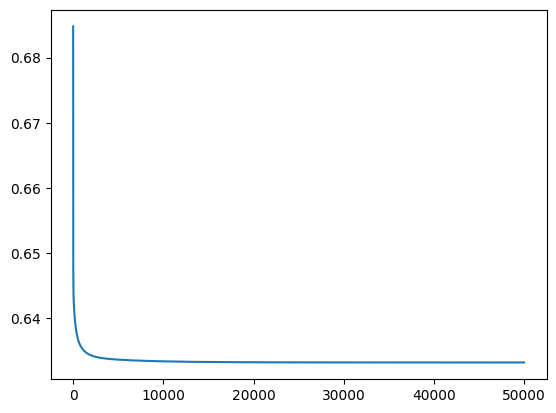

In [21]:
plt.plot(J_history2)
plt.show()

In [22]:
p3 = predict(X_poly_train_norm, w2, b2)
print(f"Train accuracy: {np.mean(p3==y_poly_train['signal'].values) * 100:0.2f}%")

X_poly_test_norm = apply_zscore_normalization(X_poly_test, X_poly_train_mu, X_poly_train_sigma, cols_to_scale)
p4 = predict(X_poly_test_norm, w2, b2)
print(f"Test Accuracy: {np.mean(p4 == y_poly_test['signal'].values) * 100:0.2f}%")

Train accuracy: 64.77%
Test Accuracy: 52.08%


In [23]:
model = LogisticRegression(penalty='l2', C=1.0, solver='liblinear')

# 2. Train the model (equivalent to your run_gradient_descent)
model.fit(X_poly_train_norm, y_poly_train['signal'])

# 3. Access the learned parameters
w_sklearn = model.coef_      
b_sklearn = model.intercept_ 

print(f"w_manual: {w2}, b_manual: {b2}"
      f"\nw_sklearn:\n{w_sklearn}, b_sklearn: {b_sklearn}")

w_manual: [ 0.10420549 -0.52079175 -0.41705808  0.12061994  0.24286792  0.44700312
  0.03788581 -0.06492184  0.19082469  0.53794669  0.32588546  0.07008246
  0.15135067  0.22252467 -0.06476562  0.37409437  0.06320299  0.01156817
  0.0409008   0.05777237  0.11835459 -0.30667039 -0.11492176  0.12208219
 -0.1908274  -0.78291617 -0.12055786], b_manual: -1.4475714946980056
w_sklearn:
[[ 0.10179246 -0.52341196 -0.47843889  0.11859555  0.12347186  0.0201555
   0.03840927 -0.06198042  0.17292855  0.52501647  0.28422003  0.18670718
   0.14868059  0.21001693 -0.06361513  0.37323257  0.0808722   0.01348472
   0.0430591   0.05394032  0.09780995 -0.33212042 -0.08975548  0.29775264
  -0.16636043 -0.70950378 -0.10325686]], b_sklearn: [-0.57824704]


c:\Users\DELL\Workspace\project_01_v2\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [24]:
y_hat3 = model.predict(X_poly_train_norm)
print(f"Accuracy on training set: {model.score(X_poly_train_norm, y_poly_train['signal']) * 100:0.2f}%")
y_hat4 = model.predict(X_poly_test_norm)
print(f"Accuracy on training set: {model.score(X_poly_test_norm, y_poly_test['signal']) * 100:0.2f}%")

Accuracy on training set: 64.59%
Accuracy on training set: 53.47%


In [25]:
np.savetxt("../data/poly/pred2.csv", p4)

In [26]:
import pickle

model_manual = {
    'weights':w2,
    'bias':b2,
    'mu':X_poly_train_mu,
    'sigma':X_poly_train_sigma,
    'features_to_scale':cols_to_scale
}

with open('../model.pkl', 'wb') as f:
    pickle.dump(model_manual, f)

In [27]:
with open('../model.pkl', 'rb') as f:
    params = pickle.load(f)

params

{'weights': array([ 0.10420549, -0.52079175, -0.41705808,  0.12061994,  0.24286792,
         0.44700312,  0.03788581, -0.06492184,  0.19082469,  0.53794669,
         0.32588546,  0.07008246,  0.15135067,  0.22252467, -0.06476562,
         0.37409437,  0.06320299,  0.01156817,  0.0409008 ,  0.05777237,
         0.11835459, -0.30667039, -0.11492176,  0.12208219, -0.1908274 ,
        -0.78291617, -0.12055786]),
 'bias': np.float64(-1.4475714946980056),
 'mu': volume                         9201525.6228
 pct_change_1d                        0.0003
 rsi                                 49.3891
 adx                                 30.9555
 volume^2               113940607513274.0156
 pct_change_1d^2                      0.0003
 rsi^2                             2610.6490
 adx^2                             1103.5280
 volatility^2                         4.1753
 volume*pct_change_1d             15000.2676
 volume*rsi                   468402921.7569
 volume*adx                   294070887.1651
